# Dask Array

Материалы:
* Макрушин С.В. Лекция 11: Dask
* https://docs.dask.org/en/latest/array.html
* JESSE C. DANIEL. Data Science with Python and Dask.

In [ ]:
import numpy as np
import pandas as pd
import dask
import dask.array as da
import matplotlib.pyplot as plt

## Задачи для совместного разбора

1. Создайте массив размерностью 1000 на 300000, заполненный числами из стандартного нормального распределения. Исследуйте основные характеристики полученного массива.



In [ ]:
big_array = dask.array.random.normal(0, 1, (1000, 300000))
big_array

dask.array<normal, shape=(1000, 300000), dtype=float64, chunksize=(1000, 16777), chunktype=numpy.ndarray>

In [ ]:
ba_mean = big_array.mean()
ba_var = big_array.var()
ba_std = big_array.std()

In [ ]:
ba_mean.compute(), ba_var.compute(), ba_std.compute()

(-4.771260421436432e-05, 0.9999647877733118, 0.9999823937316655)

2. Посчитайте сумму квадратов элементов массива, созданного в задаче 1. Создайте массив `np.array` такого же размера и сравните скорость решения задачи с использование `da.array` и `np.array`

In [ ]:
big_array_np = np.random.normal(0, 1, (1000, 300000))

In [ ]:
%timeit (big_array**2).sum()

3.79 ms ± 561 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%timeit (big_array_np**2).sum()

433 ms ± 7.01 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)




3. Визуализируйте граф вычислений для задачи 12.

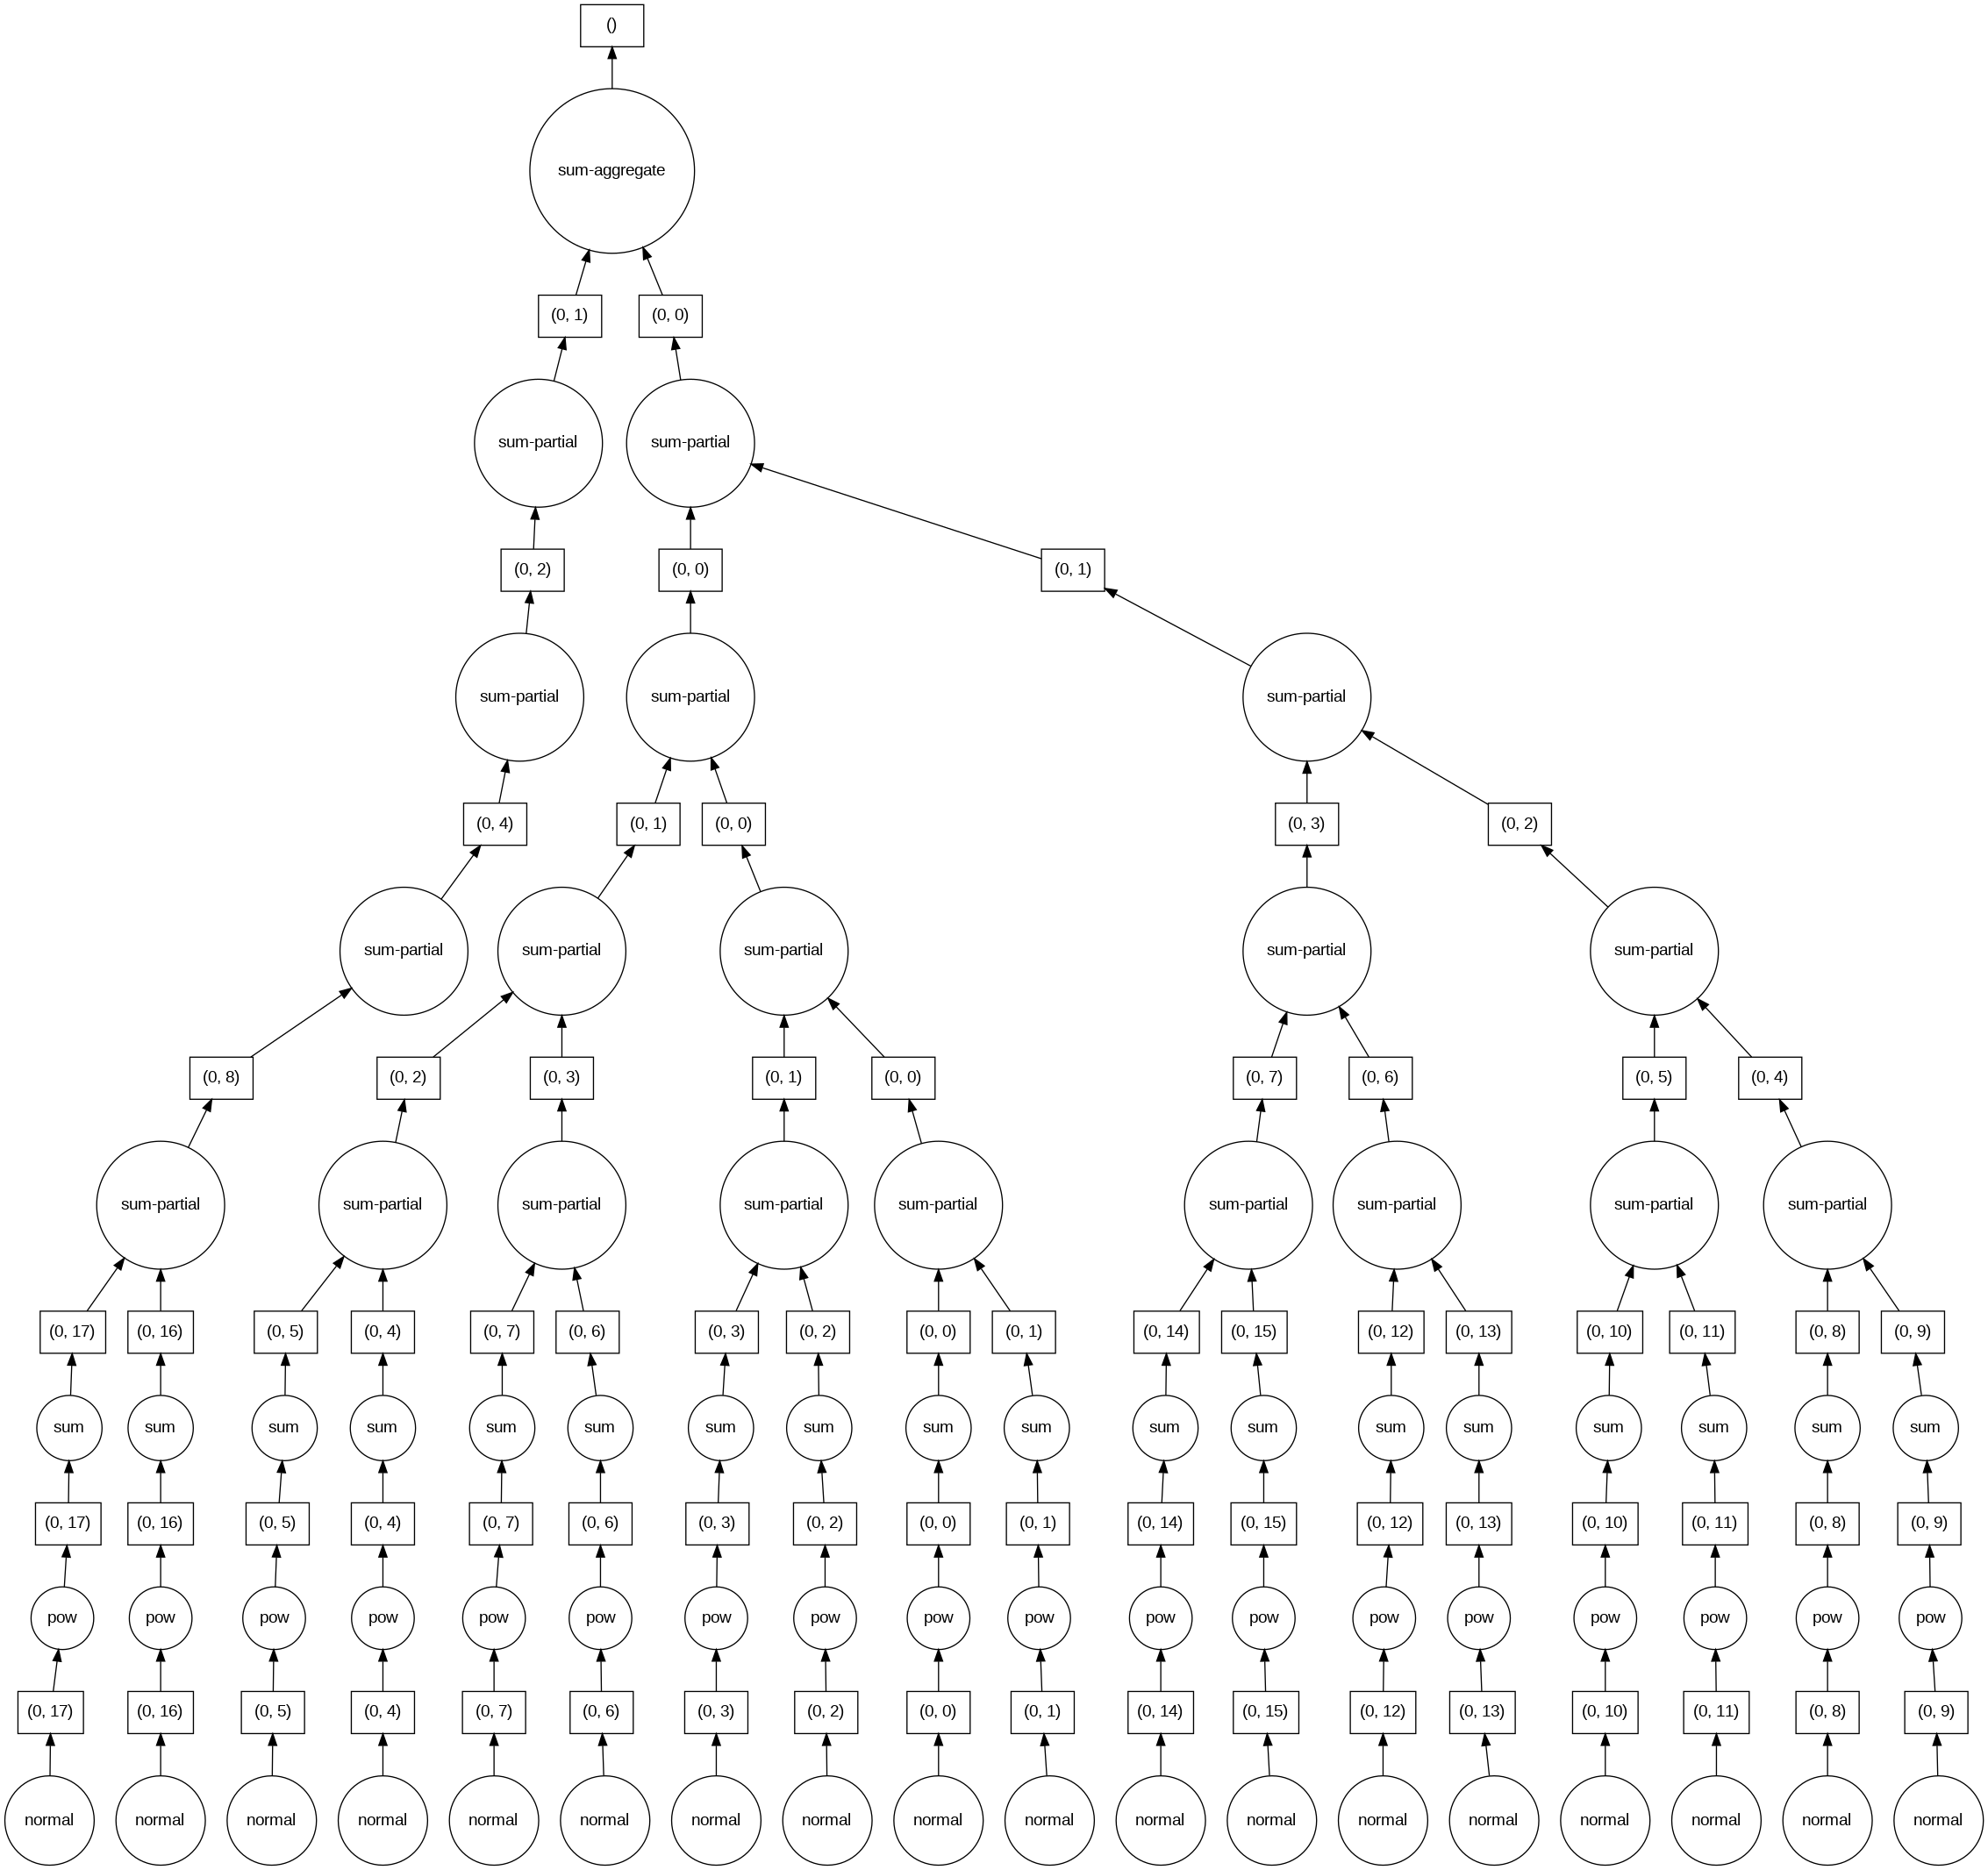

In [ ]:
res = (big_array**2).sum()
res.visualize()

## Лабораторная работа 11

In [ ]:
import dask.array as da
import h5py
import numpy as np

In [ ]:
%cd /content/drive/MyDrive/ФУППРФ/5 семестр/Технологии обработки больших данных/data

/content/drive/MyDrive/ФУППРФ/5 семестр/Технологии обработки больших данных/data


1. Считайте датасет `recipe` из файла `minutes_n_ingredients_full.hdf5` в виде `dask.array`. Укажите аргумент `chunks=(100_000, 3)` при создании массива. Выведите на экран основную информацию о массиве.



In [ ]:
recipies_file  = h5py.File('minutes_n_ingredients_full.hdf5', 'r')
recipies_file.values()

ValuesViewHDF5(<HDF5 file "minutes_n_ingredients_full.hdf5" (mode r)>)

In [ ]:
da_recipies = da.from_array(recipies_file['recipe'], chunks=(100_000, 3))
da_recipies

dask.array<array, shape=(2231637, 3), dtype=int64, chunksize=(100000, 3), chunktype=numpy.ndarray>

2. Вычислите среднее значение по каждому столбцу, кроме первого.

In [ ]:
da_recipies[:, 1:].mean(axis=0).compute()

array([1004.20805176,    5.4198008 ])

3. Исследуйте, как влияет значение аргумента `chunks` при создании `dask.array` на скорость выполнения операции поиска среднего.

In [ ]:
def recipies_mean(recipies_data):
  recipies_data[:, 1:].mean(axis=0).compute()

In [ ]:
size_chunks = np.logspace(3, 6, num=10)
diff_chunks = {int(size_chunk): da.from_array(recipies_file['recipe'], chunks=(int(size_chunk), 3)) for size_chunk in size_chunks}
times = []
for chunk, dataset in diff_chunks.items():
  print(f'chunk_size = ({chunk}, 3)')
  r = %timeit -o recipies_mean(dataset)
  times.append(r)

chunk_size = (1000, 3)
1.32 s ± 63.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
chunk_size = (2154, 3)
640 ms ± 17.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
chunk_size = (4641, 3)
308 ms ± 5.07 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
chunk_size = (10000, 3)
170 ms ± 25.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
chunk_size = (21544, 3)
111 ms ± 11.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
chunk_size = (46415, 3)
91.6 ms ± 20.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
chunk_size = (100000, 3)
67.5 ms ± 638 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
chunk_size = (215443, 3)
77.5 ms ± 21.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
chunk_size = (464158, 3)
64.5 ms ± 828 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
chunk_size = (1000000, 3)
80.3 ms ± 16 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
print(size_chunks)

[   1000.            2154.43469003    4641.58883361   10000.
   21544.34690032   46415.88833613  100000.          215443.46900319
  464158.88336128 1000000.        ]


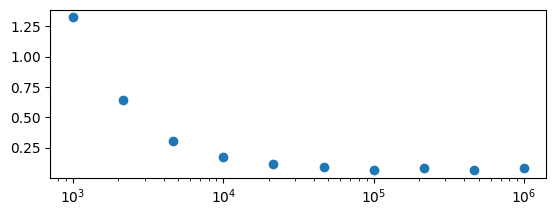

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)
ax.set_xscale('log')
ax.scatter(size_chunks, list(map(lambda tr: tr.average, times)))

4. Выберите рецепты, время выполнения которых меньше медианного значения

In [ ]:
da_recipies[da_recipies[:, 1] < da.median(da_recipies[:, 1], axis=0)].compute()

array([[1089012,      23,       5],
       [1428572,       0,       5],
       [1400250,      24,       1],
       ...,
       [1029131,      19,       4],
       [1700703,       1,       1],
       [ 713836,       0,       9]])


5. Посчитайте количество каждого из возможных значений кол-ва ингредиентов



In [ ]:
unique, unique_counts = da.unique(da_recipies[:, 2], return_counts=True)
pd.DataFrame.from_dict({'unique': unique.compute(), 'count': unique_counts.compute()})

,unique,count
0,1,222071
1,2,224158
2,3,229388
3,4,234948
4,5,240720
5,6,244360
6,7,247181
7,8,246747
8,9,246816
9,10,22430


6. Найдите максимальную продолжительность рецепта. Ограничьте максимальную продолжительность рецептов сверху значением, равному 75% квантилю.



In [ ]:
da_recipies[:, 1].max().compute()

2147483647

In [ ]:
da_recipies[da_recipies[:, 1] < da.percentile(da.ravel(da_recipies[:, 1]), 75)[0]].compute()

array([[ 683970,      33,       9],
       [1089012,      23,       5],
       [1428572,       0,       5],
       ...,
       [1029131,      19,       4],
       [1700703,       1,       1],
       [ 713836,       0,       9]])

7. Создайте массив `dask.array` из 2 чисел, содержащих ваши предпочтения относительно времени выполнения рецепта и кол-ва ингредиентов. Найдите наиболее похожий (в смысле $L_1$) рецепт из имеющихся в датасете.



In [ ]:
my = da.from_array([4390, 19])

In [ ]:
da_recipies[((da_recipies[:, 1:] - my)**2).sum(axis=1).argmin()].compute()

array([44150,  4395,    22])

8. Работая с исходным файлом в формате `hdf5`, реализуйте алгоритм подсчета среднего значения в блочной форме и вычислите с его помощью среднее значение второго столбца в массиве.

Блочный алгоритм вычислений состоит из двух частей:
1. Загрузка фрагмента за фрагментом данных по `blocksize` элементов и проведение вычислений на этим фрагментом
2. Агрегация результатов вычислений на различных фрагментах для получения результата на уровне всего набора данных

Важно: при работе с `h5py` в память загружаются не все элементы, а только те, которые запрашиваются в данный момент

In [ ]:
recipies_file  = h5py.File('minutes_n_ingredients_full.hdf5', 'r')

In [ ]:
recipies = recipies_file['recipe']
blocksize = 100_000
block_means = []
sums = 0
for start in range(0, len(recipies), blocksize):
  end = start + blocksize
  end = len(recipies) if end > len(recipies) else end
  fullness = (end - start)/blocksize
  sums += recipies[start:end, 1].sum()
sums/len(recipies)

1004.2080517575215

In [ ]:
recipies[:, 1].mean()

1004.2080517575215